In [9]:
from library import *
recording = '6-13-24'
VID_DIR = './pumpkin_videos/' + recording
OUT_DIR = './pumpkin_videos/' + recording + '/outputs'
# videos = [
#           'eat2_fs_00001', 'eat2_fs_00002', 'eat2_fs_00003', 'eat2_fs_00004', 'eat2_fs_00005',
#           'eat2_ss_00001', 'eat2_ss_00002', 'eat2_ss_00003', 'eat2_ss_00004', 'eat2_ss_00005',
#           'eat2_ff_00001', 'eat2_ff_00002', 'eat2_ff_00003', 'eat2_ff_00004', 'eat2_ff_00005',
#           'eat2_sf_00001', 'eat2_sf_00002', 'eat2_sf_00003', 'eat2_sf_00004', 'eat2_sf_00005',
#           'n2_fs_00001',   'n2_fs_00002',   'n2_fs_00003',   'n2_fs_00004',   'n2_fs_00005',
#           'n2_ss_00001',   'n2_ss_00002',   'n2_ss_00003',   'n2_ss_00004',   'n2_ss_00005',
#           'n2_ff_00001',   'n2_ff_00002',   'n2_ff_00003',   'n2_ff_00004',   'n2_ff_00005',
#           'n2_sf_00001',   'n2_sf_00002',   'n2_sf_00003',   'n2_sf_00004',   'n2_sf_00005',
# ]
# videos = ['eat2_fs_00001', 'eat2_fs_00002', 'eat2_fs_00003', 'eat2_fs_00004', 'eat2_fs_00005',
#           'eat2_ss_00001', 'eat2_ss_00002', 'eat2_ss_00003', 'eat2_ss_00004', 'eat2_ss_00005',
#           'n2_fs_00001',   'n2_fs_00002',   'n2_fs_00003',   'n2_fs_00004',   'n2_fs_00005',
#           'n2_ss_00001',   'n2_ss_00002',   'n2_ss_00003',   'n2_ss_00004',   'n2_ss_00005',
# ]
# videos = ['eat2_fs_00001','eat2_ss_00002', 'eat2_ss_00003', 'eat2_ss_00004', 'eat2_ss_00005',          
# ]
videos = ['eat2_fs_00001']

In [16]:
### Set parameters
ROI_width = 125   # resulting video will be 2*roi_width x 2*roi_width
thresh    = 250   # threshold for filtering ROI coordinates
sig       = 7     # sigma used for smoothing the ROI centers
SAVE      = True  # flag to determine whether ROIs will be saved

### Dynamically crop all videos in recording
for video in videos:
    ### Load data
    fullName = video + '.wmv'
    vidPath  = VID_DIR + '/original_videos/' + fullName

    bboxName = OUT_DIR + '/pharbulb/' + video + '_boxes.csv'
    boxes    = pd.read_csv(bboxName)
    boxes    = boxes.to_numpy()

    ### Load video
    vid        = cv2.VideoCapture(vidPath)
    width      = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
    height     = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps        = vid.get(cv2.CAP_PROP_FPS)
    tot_frames = int(vid.get(cv2.CAP_PROP_FRAME_COUNT)) 

    # Create name for output video
    fileName = VID_DIR + '/cropped/' + video + '_cropped.wmv'
    vwriter  = cv2.VideoWriter(fileName,
                              cv2.VideoWriter_fourcc('M','J','P','G'),
                              fps, (2*ROI_width, 2*ROI_width))

    # Get unfiltered ROI coordinates
    ROI_coords = np.zeros((tot_frames,2)) # array to store tracked bulb centers
    for f in range(0,tot_frames-1):
        # Grab the center of each tracked pharyngeal bulb, then process after
        ROI = boxes[f].astype('int')
        ROI_coords[f] = [np.mean([ROI[0], ROI[2]]).astype('int'), np.mean([ROI[1], ROI[3]]).astype('int')]
    
    # Filter and smooth ROI coordinates
    ROI_coords_i, ROI_coords_s = filter_ROIs(ROI_coords, threshold=thresh, sigma=sig, max_values=(3840,2160))

    # Save bulb centers
    if SAVE:
        ROIPath = OUT_DIR + '/pharbulb/ROI/' + video + '_ROI.csv'
        saveROICoords = pd.DataFrame(ROI_coords_s)
        saveROICoords.to_csv(ROIPath, index=False) 

    ## SECOND LOOP: crop the video frame by frame
    f = 1
    success = True
    while success and f < tot_frames:
        # Read next frame
        success, frame = vid.read()

        if success and f < tot_frames:
            print("frame: ", f-1)

            # Crop out the ROI from the current frame
            ROI = getROI(ROI_width, ROI_coords_s[f], frame, width, height)

            # Save roi frame to video
            vwriter.write(ROI)

        # Move to next frame
        f += 1
        clear_output(wait=True)

    vwriter.release()
    clear_output(wait=True)
    print("Saved to ", fileName)

Saved to  ./pumpkin_videos/6-13-24/cropped/eat2_fs_00001_cropped.wmv


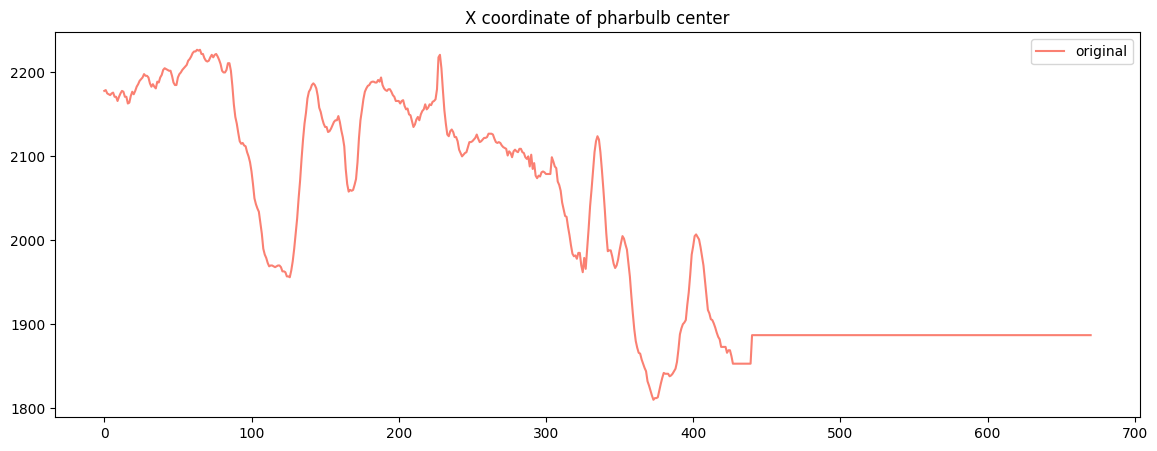

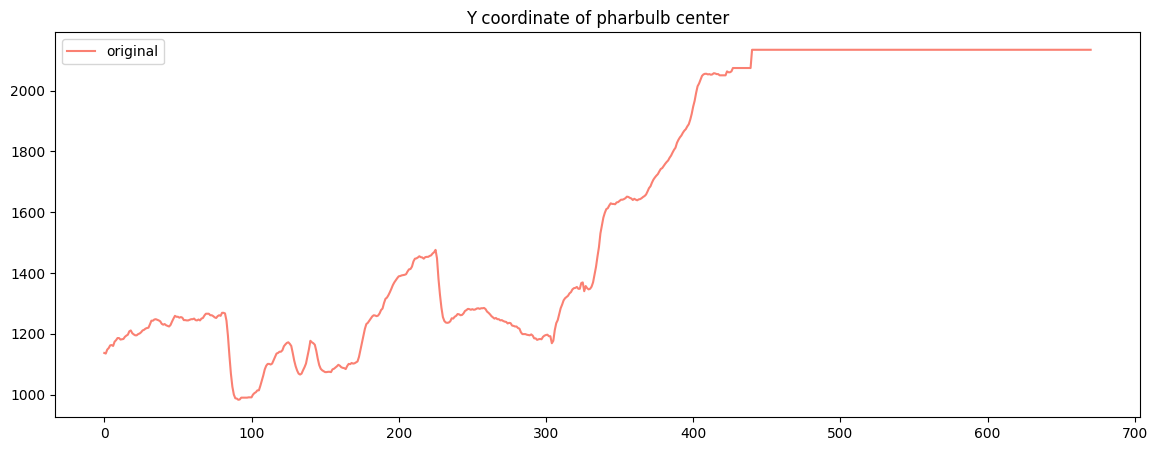

In [17]:
#### OPTIONAL: Save plots that smoothing + interpolated pharbulb centers compared to original
#figName = PB_PLOT_DIR + '/' + vidName + '_pharbulbX.png'
plt.figure(figsize=(14,5))
plt.plot(ROI_coords[:,0],color='salmon',label='original')
#plt.plot(ROI_coords_i[:,0],color='goldenrod',label='interpolated')
#plt.plot(ROI_coords_s[:,0],color='cornflowerblue',label='smoothed')
plt.legend()
plt.title('X coordinate of pharbulb center')
#plt.savefig(figName)
plt.show()

#figName = PB_PLOT_DIR + '/' + vidName + '_pharbulbY.png'
plt.figure(figsize=(14,5))
plt.plot(ROI_coords[:,1],color='salmon',label='original')
#plt.plot(ROI_coords_i[:,1],color='goldenrod',label='interpolated')
#plt.plot(ROI_coords_s[:,1],color='cornflowerblue',label='smoothed')
plt.legend()
plt.title('Y coordinate of pharbulb center')
#plt.savefig(figName)
plt.show()

---
### Crop folder of images
Don't forget to check how your annotations are sorted vs. how the images are sorted/read :)

In [4]:
### Set parameters
ROI_width = 125 # resulting images will be 2*roi_width x 2*roi_width

### Load data
mainName   = './images/test_videos/'
videoName  = 'eat2_sf_w_00003'
folderName = mainName + videoName

bboxName   = folderName + '/bulb_boxes.csv'
boxes      = pd.read_csv(bboxName)
boxes      = boxes.to_numpy()
boxes      = boxes[:,1:5]

In [5]:
### Main loop for loading original images and saving ROI images
## Get coordinates for ROI centers and crop the images
f = 0
imagePath = glob.glob(f"{folderName}/*.png")
all_images = [image_path.split('/')[-1] for image_path in imagePath]
all_images = sorted(all_images)
tot_images = len(all_images)
ROI_coords = np.zeros((tot_images,2)) # array to store tracked bulb centers

while f < tot_images:
    # Grab the center of each tracked pharyngeal bulb
    print("frame: ", f)
    ROI = boxes[f].astype('int')

    ROI_coords[f] = [np.mean([ROI[0], ROI[2]]), np.mean([ROI[1], ROI[3]])]
    #ROI_coords[f] = [np.mean([ROI[1], ROI[3]]), np.mean([ROI[0], ROI[2]])]

    # Load the image
    image = cv2.imread(folderName + '/' + all_images[f])

    # Crop the image
    # if the image has a labeled pharyngeal bulb, crop it
    if np.sum(ROI_coords[f]) > 0: 
        ROI = getROI(ROI_width, ROI_coords[f].astype('int'), image, int(image.shape[1]), int(image.shape[0]))

        # Save the image
        cv2.imwrite(folderName + '/cropped/' + all_images[f], ROI)
    
    # Move to next frame
    f += 1
    clear_output(wait=True)

# Save bulb centers
#ROIPath = folderName + '/test_ROIs.csv'
#saveROICoords = pd.DataFrame(ROI_coords)
#saveROICoords.to_csv(ROIPath, index=False) 

clear_output(wait=True)
#print("Saved to ", ROIPath)
print("Done")

Done
